In [18]:
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
# 1. 데이터 불러오기
data = pd.read_csv(
    '최종회의_반영_완성본.csv',
    encoding='utf-8-sig',
    low_memory=False
)

# 2. 분석 범위 확인
print(data.shape)
print(data[['거래금액_만원', '복도유형', '반경500m_버스정류장', '경사도',
            '역세권여부', '브랜드_Top20_여부', '고층여부', '단지내_편의시설_유무']].head())

# 3. 결측치 확인
eda_cols = [
    '거래금액_만원',
    '복도유형',
    '반경500m_버스정류장',
    '경사도',
    '역세권여부',
    '브랜드_Top20_여부',
    '고층여부',
    '단지내_편의시설_유무'
]

print(data[eda_cols].isnull().sum())

(11087, 70)
   거래금액_만원 복도유형  반경500m_버스정류장       경사도  역세권여부  브랜드_Top20_여부  고층여부  \
0    60000  혼합식            25  6.363689    0.0             0     0   
1    11550  복도식            32  0.930472    1.0             0     0   
2    97500  계단식            36  4.918667    0.0             1     0   
3    84000  계단식             8  4.318167    1.0             0     0   
4    11025  복도식            32  0.930472    1.0             0     0   

   단지내_편의시설_유무  
0            0  
1            0  
2            0  
3            0  
4            0  
거래금액_만원         0
복도유형            0
반경500m_버스정류장    0
경사도             0
역세권여부           0
브랜드_Top20_여부    0
고층여부            0
단지내_편의시설_유무     0
dtype: int64


복도유형EDA

      거래건수        평균거래금액      중앙값
복도유형                             
계단식   5852  88800.212748  86500.0
혼합식   4668  76879.571337  72500.0
복도식    567  52617.169312  60000.0


C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph

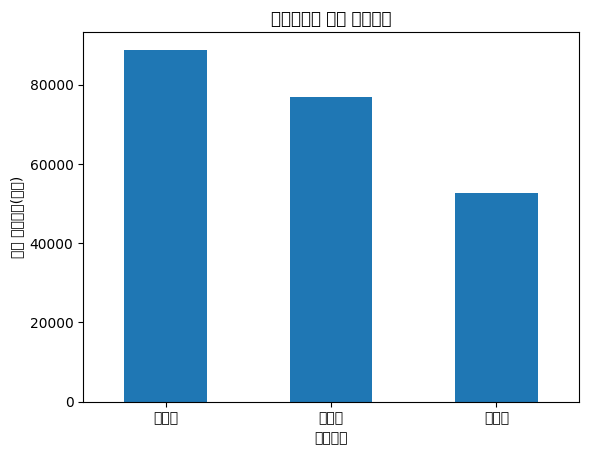

In [20]:
corridor_summary = data.groupby('복도유형')['거래금액_만원'].agg(
    거래건수='count',
    평균거래금액='mean',
    중앙값='median'
).sort_values('평균거래금액', ascending=False)

print(corridor_summary)

corridor_summary['평균거래금액'].plot(kind='bar')

plt.xlabel('복도유형')
plt.ylabel('평균 거래금액(만원)')
plt.title('복도유형별 평균 거래금액')
plt.xticks(rotation=0)
plt.show()

복도유형별 평균 거래금액을 비교한 결과, 계단식 아파트의 평균 거래금액이 가장 높고, 복도식 아파트의 평균 거래금액이 가장 낮게 나타났다. 이는 계단식 구조가 일반적으로 세대 프라이버시, 채광, 환기 측면에서 선호될 수 있고, 복도식 아파트는 상대적으로 오래된 단지나 소형 평형에 많이 나타날 수 있기 때문으로 해석할 수 있다. 다만 복도유형 자체의 효과라기보다 건물나이, 전용면적, 단지 특성과 함께 해석할 필요가 있다.

반경 500m 버스정류장 수

C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48260 (\N{HANGUL SYLLABLE BEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 

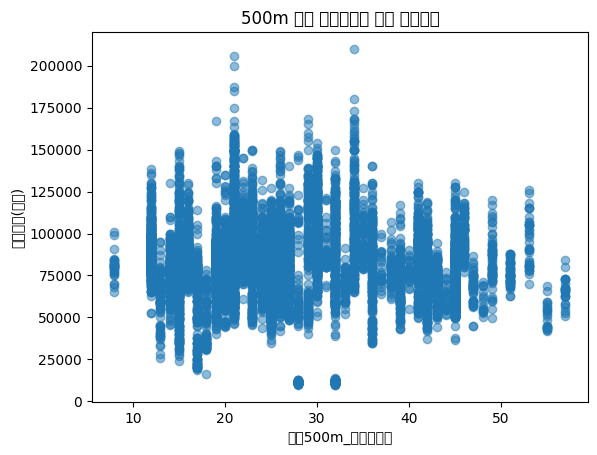

In [21]:
plt.scatter(data['반경500m_버스정류장'], data['거래금액_만원'], alpha=0.5)

plt.xlabel('반경500m_버스정류장')
plt.ylabel('거래금액(만원)')
plt.title('500m 반경 버스정류장 수와 거래금액')
plt.show()


               거래건수        평균거래금액      중앙값
버스정류장수_구간                                 
(7.999, 20.0]  2808  78002.234687  78000.0
(20.0, 25.0]   2980  85809.412752  83550.0
(25.0, 34.0]   2758  85891.401378  86000.0
(34.0, 57.0]   2541  77424.560803  75700.0


C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph

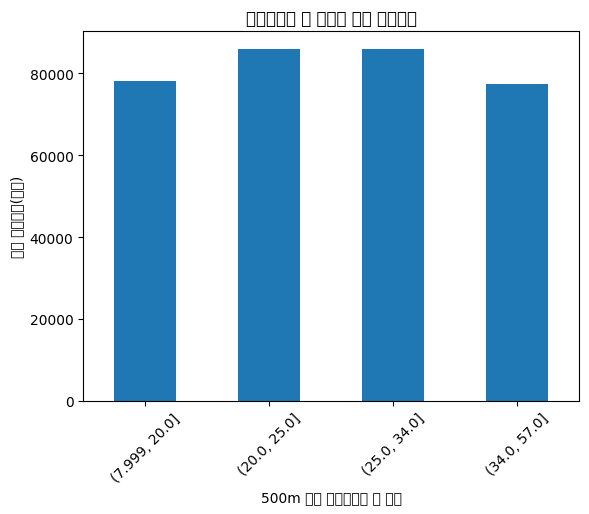

In [22]:
data['버스정류장수_구간'] = pd.qcut(
    data['반경500m_버스정류장'],
    q=4,
    duplicates='drop'
)

bus_summary = data.groupby('버스정류장수_구간')['거래금액_만원'].agg(
    거래건수='count',
    평균거래금액='mean',
    중앙값='median'
)

print(bus_summary)

bus_summary['평균거래금액'].plot(kind='bar')

plt.xlabel('500m 반경 버스정류장 수 구간')
plt.ylabel('평균 거래금액(만원)')
plt.title('버스정류장 수 구간별 평균 거래금액')
plt.xticks(rotation=45)
plt.show()

?????????

경사도 EDA

C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


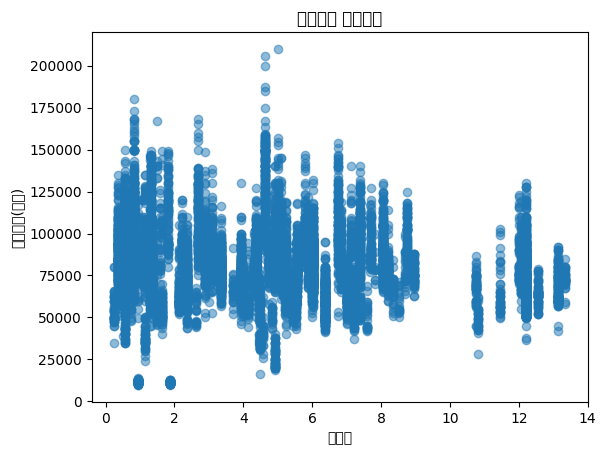

In [23]:
plt.scatter(data['경사도'], data['거래금액_만원'], alpha=0.5)

plt.xlabel('경사도')
plt.ylabel('거래금액(만원)')
plt.title('경사도와 거래금액')
plt.show()

                 거래건수        평균거래금액      중앙값
경사도_구간                                      
(0.257, 1.632]   2808  85639.946225  87000.0
(1.632, 4.643]   2850  83225.084561  80500.0
(4.643, 6.839]   2741  80838.431229  80000.0
(6.839, 13.353]  2688  77797.626116  75500.0


C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph

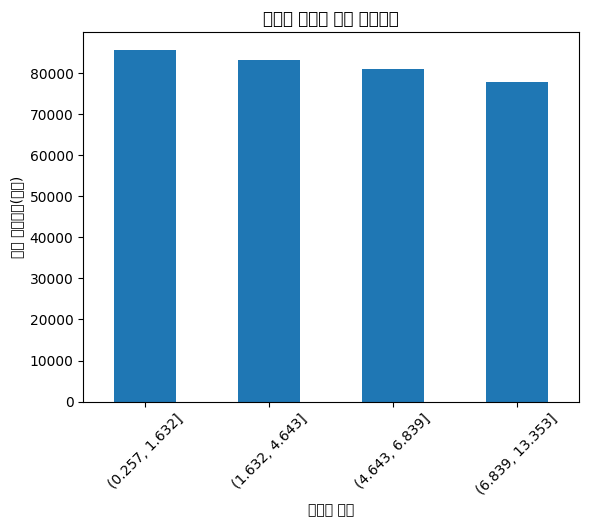

In [24]:
data['경사도_구간'] = pd.qcut(
    data['경사도'],
    q=4,
    duplicates='drop'
)

slope_summary = data.groupby('경사도_구간')['거래금액_만원'].agg(
    거래건수='count',
    평균거래금액='mean',
    중앙값='median'
)

print(slope_summary)

slope_summary['평균거래금액'].plot(kind='bar')

plt.xlabel('경사도 구간')
plt.ylabel('평균 거래금액(만원)')
plt.title('경사도 구간별 평균 거래금액')
plt.xticks(rotation=45)
plt.show()

경사도는 거래금액과 약한 음의 상관관계를 보였다. 경사도 구간별 평균 거래금액을 확인한 결과, 경사도가 낮은 구간일수록 평균 거래금액이 높고, 경사도가 높은 구간일수록 평균 거래금액이 낮아지는 경향이 나타났다. 이는 경사가 큰 지역일수록 보행 접근성이나 생활 편의성이 떨어질 수 있기 때문으로 해석할 수 있다.

역세권 여부 EDA

C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph

       거래건수        평균거래금액      중앙값
역세권여부                             
0.0    6990  79780.202289  79300.0
1.0    4097  85599.952404  83500.0


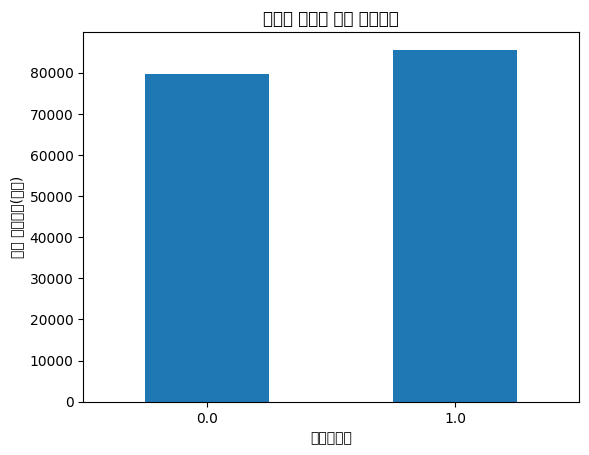

In [25]:
station_summary = data.groupby('역세권여부')['거래금액_만원'].agg(
    거래건수='count',
    평균거래금액='mean',
    중앙값='median'
)

print(station_summary)

station_summary['평균거래금액'].plot(kind='bar')

plt.xlabel('역세권여부')
plt.ylabel('평균 거래금액(만원)')
plt.title('역세권 여부별 평균 거래금액')
plt.xticks(rotation=0)
plt.show()

브랜드 Top20 여부 EDA

              거래건수        평균거래금액      중앙값
브랜드_Top20_여부                             
0             5526  71222.260043  70000.0
1             5561  92571.913325  90000.0


C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph

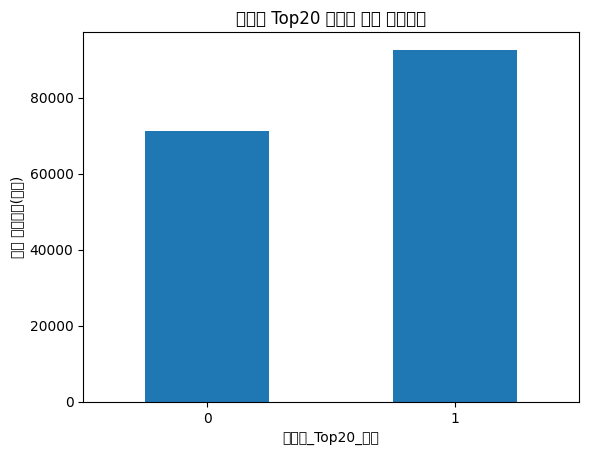

In [26]:
brand_summary = data.groupby('브랜드_Top20_여부')['거래금액_만원'].agg(
    거래건수='count',
    평균거래금액='mean',
    중앙값='median'
)

print(brand_summary)

brand_summary['평균거래금액'].plot(kind='bar')

plt.xlabel('브랜드_Top20_여부')
plt.ylabel('평균 거래금액(만원)')
plt.title('브랜드 Top20 여부별 평균 거래금액')
plt.xticks(rotation=0)
plt.show()

고층여부 EDA (!)

C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


      거래건수        평균거래금액      중앙값
고층여부                             
0     8809  80018.717221  79000.0
1     2278  89324.731782  86350.0


C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 5

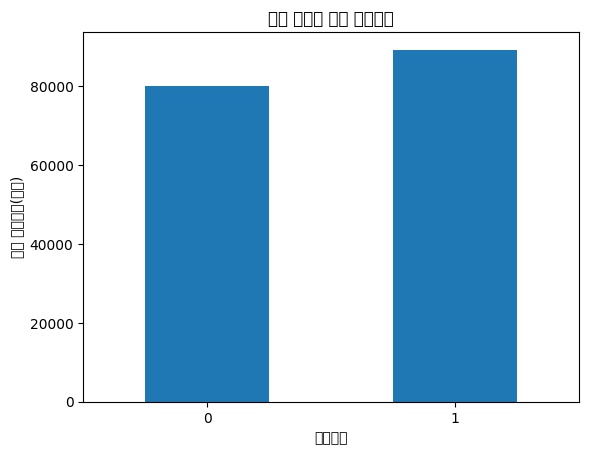

In [27]:
high_summary = data.groupby('고층여부')['거래금액_만원'].agg(
    거래건수='count',
    평균거래금액='mean',
    중앙값='median'
)

print(high_summary)

high_summary['평균거래금액'].plot(kind='bar')

plt.xlabel('고층여부')
plt.ylabel('평균 거래금액(만원)')
plt.title('고층 여부별 평균 거래금액')
plt.xticks(rotation=0)
plt.show()

단지 내 편의시설 유무 EDA

              거래건수        평균거래금액      중앙값
단지내_편의시설_유무                              
0            10093  80649.632319  80000.0
1              994  94939.517103  96000.0


C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph

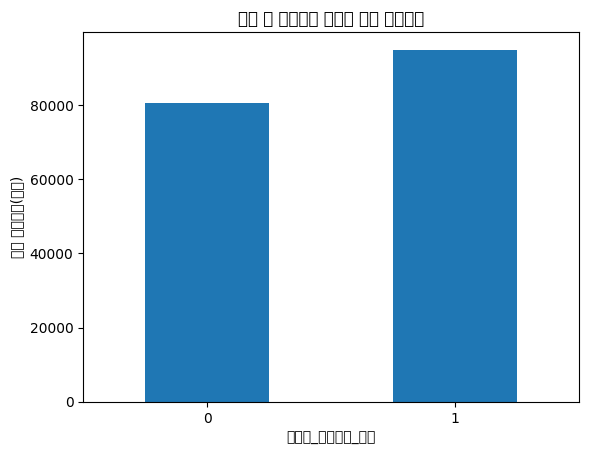

In [28]:
facility_summary = data.groupby('단지내_편의시설_유무')['거래금액_만원'].agg(
    거래건수='count',
    평균거래금액='mean',
    중앙값='median'
)

print(facility_summary)

facility_summary['평균거래금액'].plot(kind='bar')

plt.xlabel('단지내_편의시설_유무')
plt.ylabel('평균 거래금액(만원)')
plt.title('단지 내 편의시설 유무별 평균 거래금액')
plt.xticks(rotation=0)
plt.show()

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
data = pd.read_csv(
    '최종회의_반영_완성본_고층변수수정.csv',
    encoding='utf-8-sig',
    low_memory=False
)

# 2. 타깃 변수
target_col = '거래금액_만원'

# 3. 내 담당 변수
my_numeric_cols = [
    '거래금액_만원',
    '반경500m_버스정류장',
    '경사도',
    '역세권여부',
    '브랜드_Top20_여부',
    '고층아파트단지여부',
    '고층세대여부',
    '단지내_편의시설_유무'
]

# 실제 존재하는 컬럼만 사용
my_numeric_cols = [col for col in my_numeric_cols if col in data.columns]

# 4. 숫자형 변환
for col in my_numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# 5. 결측치 확인
print("담당 변수 결측치 확인")
print(data[my_numeric_cols + ['복도유형']].isnull().sum())

# 6. 숫자형/이진 변수 상관계수 확인
my_corr = data[my_numeric_cols].corr()[target_col].sort_values(ascending=False)

print("\n[숫자형/이진 담당 변수와 거래금액의 상관계수]")
print(my_corr)

담당 변수 결측치 확인
거래금액_만원         0
반경500m_버스정류장    0
경사도             0
역세권여부           0
브랜드_Top20_여부    0
고층아파트단지여부       0
고층세대여부          1
단지내_편의시설_유무     0
복도유형            0
dtype: int64

[숫자형/이진 담당 변수와 거래금액의 상관계수]
거래금액_만원         1.000000
브랜드_Top20_여부    0.463264
고층아파트단지여부       0.359430
단지내_편의시설_유무     0.177169
역세권여부           0.121908
고층세대여부         -0.009475
반경500m_버스정류장   -0.055126
경사도            -0.143201
Name: 거래금액_만원, dtype: float64


In [30]:
# 7. 복도유형 더미변수 생성
corridor_dummy = pd.get_dummies(
    data['복도유형'],
    prefix='복도유형'
)

# 8. 거래금액 + 담당 숫자형 변수 + 복도유형 더미변수 결합
eda_corr_data = pd.concat(
    [
        data[my_numeric_cols],
        corridor_dummy
    ],
    axis=1
)

# 9. 복도유형 포함 상관계수 확인
my_all_corr = eda_corr_data.corr()[target_col].sort_values(ascending=False)

print("\n[복도유형 포함 담당 변수와 거래금액의 상관계수]")
print(my_all_corr)


[복도유형 포함 담당 변수와 거래금액의 상관계수]
거래금액_만원         1.000000
브랜드_Top20_여부    0.463264
고층아파트단지여부       0.359430
복도유형_계단식        0.315198
단지내_편의시설_유무     0.177169
역세권여부           0.121908
고층세대여부         -0.009475
반경500m_버스정류장   -0.055126
경사도            -0.143201
복도유형_혼합식       -0.186938
복도유형_복도식       -0.295340
Name: 거래금액_만원, dtype: float64


C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49

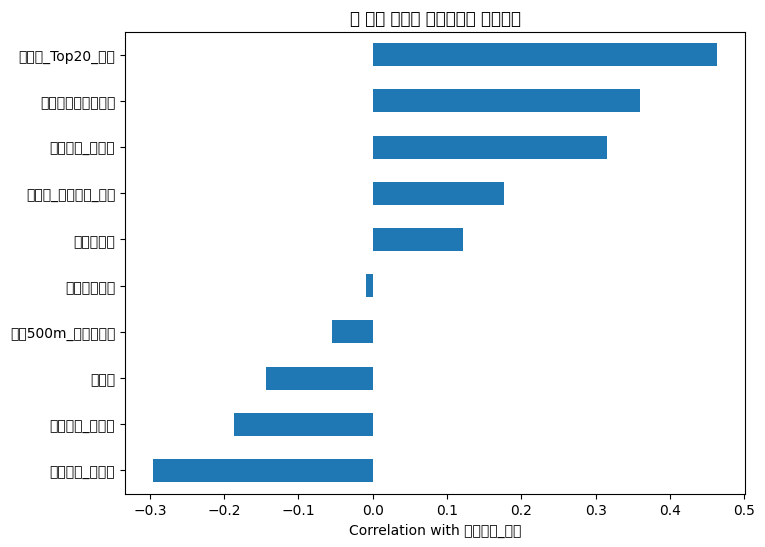

In [31]:
# 10. 거래금액 자기 자신 제외
my_all_corr_without_target = my_all_corr.drop(target_col)

# 11. 그래프 출력
my_all_corr_without_target.sort_values().plot(kind='barh', figsize=(8, 6))

plt.xlabel('Correlation with 거래금액_만원')
plt.title('내 담당 변수와 거래금액의 상관관계')
plt.show()

최고층수 기초통계
count    11087.000000
mean        21.273022
std          5.109645
min          7.000000
25%         19.000000
50%         20.000000
75%         23.000000
max         41.000000
Name: 최고층수, dtype: float64

실거래가 기초통계
count     11087.000000
mean      81930.785515
std       23043.572146
min        9800.000000
25%       67900.000000
50%       80000.000000
75%       95000.000000
max      210000.000000
Name: 거래금액_만원, dtype: float64

최고층수와 실거래가의 상관계수: 0.48029261394965483


C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 4756

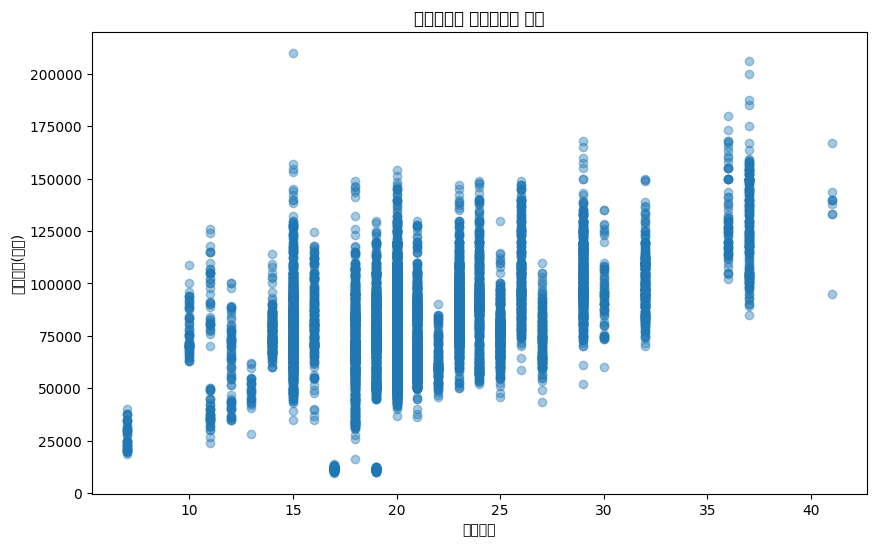


최고층수 구간별 평균 실거래가
최고층수_구간
6~10층      56336.585366
11~15층     77039.538578
16~20층     75841.753165
21~25층     81696.501254
26~30층     98838.340536
31~40층    115317.408585
41층 이상    136611.111111
Name: 거래금액_만원, dtype: float64


C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 

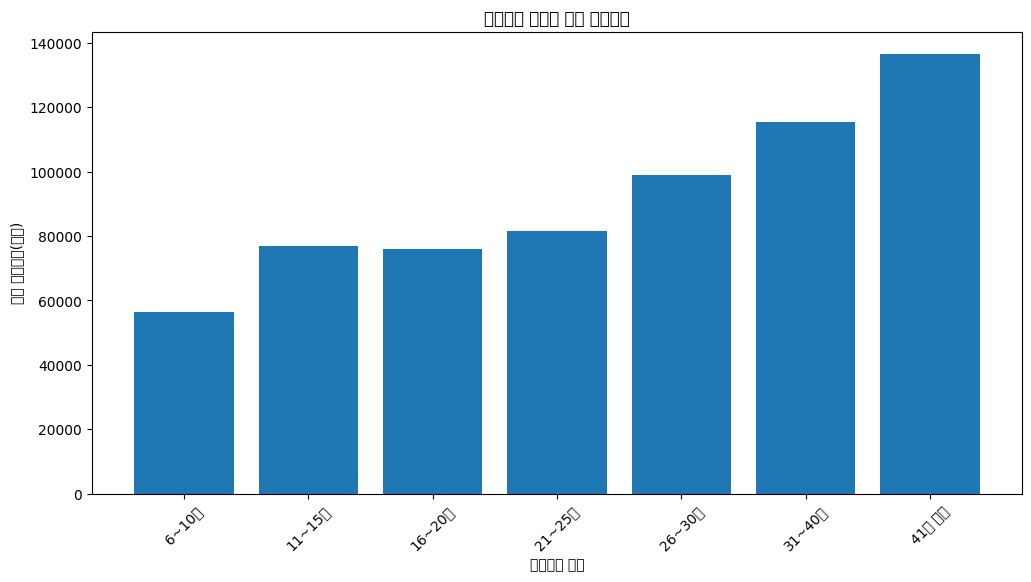

C:\Users\rlack\AppData\Local\Temp\ipykernel_30172\2259857768.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rlack\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools

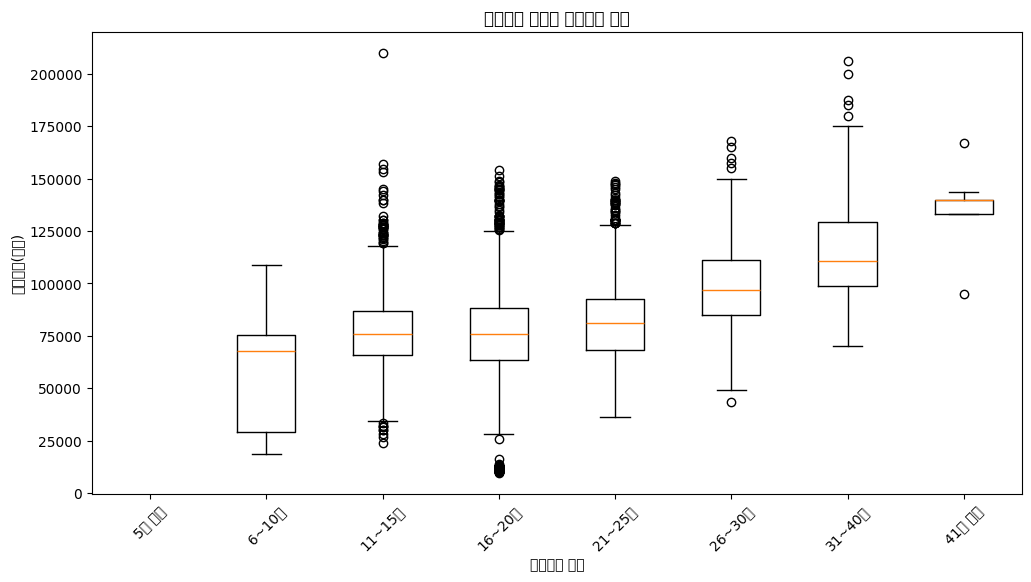

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 불러오기
df = pd.read_csv("final (1).csv", low_memory=False)

# 필요한 컬럼 숫자형 변환
df["최고층수"] = pd.to_numeric(df["최고층수"], errors="coerce")
df["거래금액_만원"] = pd.to_numeric(df["거래금액_만원"], errors="coerce")

# 최고층수와 실거래가가 모두 있는 행만 사용
eda_df = df.dropna(subset=["최고층수", "거래금액_만원"]).copy()

# 기초 통계
print("최고층수 기초통계")
print(eda_df["최고층수"].describe())

print("\n실거래가 기초통계")
print(eda_df["거래금액_만원"].describe())

# 상관계수
corr = eda_df["최고층수"].corr(eda_df["거래금액_만원"])
print("\n최고층수와 실거래가의 상관계수:", corr)

# 산점도
plt.figure(figsize=(10, 6))
plt.scatter(
    eda_df["최고층수"],
    eda_df["거래금액_만원"],
    alpha=0.4
)
plt.title("최고층수와 실거래가의 관계")
plt.xlabel("최고층수")
plt.ylabel("실거래가(만원)")
plt.show()

# 최고층수 구간화
bins = [0, 5, 10, 15, 20, 25, 30, 40, 100]
labels = [
    "5층 이하", "6~10층", "11~15층", "16~20층",
    "21~25층", "26~30층", "31~40층", "41층 이상"
]

eda_df["최고층수_구간"] = pd.cut(
    eda_df["최고층수"],
    bins=bins,
    labels=labels
)

# 구간별 평균 실거래가
price_by_max_floor = eda_df.groupby("최고층수_구간")["거래금액_만원"].mean()

print("\n최고층수 구간별 평균 실거래가")
print(price_by_max_floor)

plt.figure(figsize=(12, 6))
plt.bar(
    price_by_max_floor.index.astype(str),
    price_by_max_floor.values
)
plt.title("최고층수 구간별 평균 실거래가")
plt.xlabel("최고층수 구간")
plt.ylabel("평균 실거래가(만원)")
plt.xticks(rotation=45)
plt.show()

# 구간별 실거래가 분포
box_data = []

for label in labels:
    data = eda_df.loc[
        eda_df["최고층수_구간"] == label,
        "거래금액_만원"
    ].dropna()
    box_data.append(data)

plt.figure(figsize=(12, 6))
plt.boxplot(
    box_data,
    labels=labels
)
plt.title("최고층수 구간별 실거래가 분포")
plt.xlabel("최고층수 구간")
plt.ylabel("실거래가(만원)")
plt.xticks(rotation=45)
plt.show()

In [4]:
# 최고층수와 실거래가의 상관계수 계산
corr_value = eda_df["최고층수"].corr(eda_df["거래금액_만원"])

print("최고층수와 실거래가의 상관계수:", corr_value)

최고층수와 실거래가의 상관계수: 0.48029261394965483


실거래가와 각 변수의 상관계수
거래금액_만원          1.000000
전용면적             0.576206
최고층수             0.480293
브랜드_Top20_여부     0.463264
복도유형_계단식         0.315198
층                0.207686
단지내_편의시설_유무      0.177169
역세권여부            0.121908
500m내_편의시설_총합    0.115703
세대당_주차대수        -0.013433
반경500m_버스정류장    -0.055126
기준금리            -0.126746
경사도             -0.143201
복도유형_혼합식        -0.186938
고도              -0.290430
복도유형_복도식        -0.295340
건물나이            -0.504039
Name: 거래금액_만원, dtype: float64


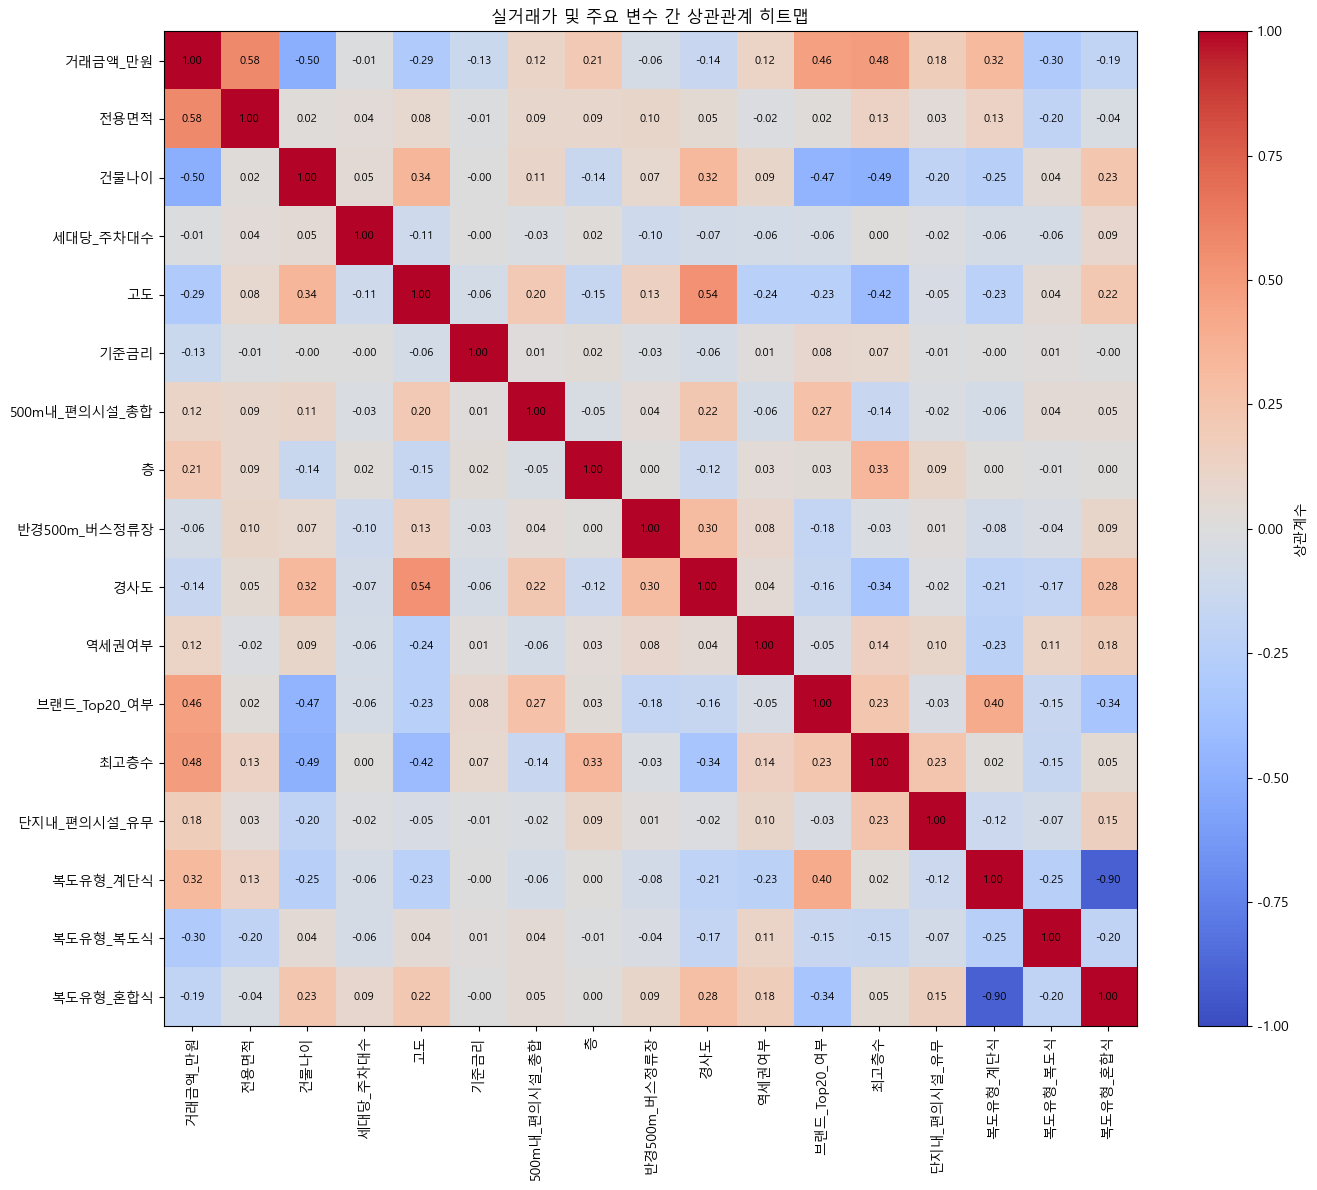

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 데이터 불러오기
df = pd.read_csv("final (1).csv", low_memory=False)

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"   # Windows
plt.rcParams["axes.unicode_minus"] = False

# 사용할 변수 목록
selected_cols = [
    "거래금액_만원",
    "전용면적",
    "건물나이",
    "세대당_주차대수",
    "고도",
    "기준금리",
    "500m내_편의시설_총합",
    "층",
    "복도유형",
    "반경500m_버스정류장",
    "경사도",
    "역세권여부",
    "브랜드_Top20_여부",
    "최고층수",
    "단지내_편의시설_유무"
]

# 필요한 컬럼만 추출
eda_df = df[selected_cols].copy()

# 숫자형 변수 변환
numeric_cols = [
    "거래금액_만원",
    "전용면적",
    "건물나이",
    "세대당_주차대수",
    "고도",
    "기준금리",
    "500m내_편의시설_총합",
    "층",
    "반경500m_버스정류장",
    "경사도",
    "역세권여부",
    "브랜드_Top20_여부",
    "최고층수",
    "단지내_편의시설_유무"
]

for col in numeric_cols:
    eda_df[col] = pd.to_numeric(eda_df[col], errors="coerce")

# 복도유형 원-핫 인코딩
eda_df = pd.get_dummies(
    eda_df,
    columns=["복도유형"],
    drop_first=False
)

# 결측치 제거
eda_df = eda_df.dropna()

# 상관계수 계산
corr = eda_df.corr()

# 실거래가와의 상관계수만 따로 출력
target_corr = corr["거래금액_만원"].sort_values(ascending=False)

print("실거래가와 각 변수의 상관계수")
print(target_corr)

# 히트맵 시각화
plt.figure(figsize=(14, 12))

plt.imshow(corr, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="상관계수")

plt.xticks(
    ticks=np.arange(len(corr.columns)),
    labels=corr.columns,
    rotation=90
)

plt.yticks(
    ticks=np.arange(len(corr.index)),
    labels=corr.index
)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("실거래가 및 주요 변수 간 상관관계 히트맵")
plt.tight_layout()
plt.show()